# RetailPulse

## Dataset Loading and Initial Exploration

Author: Anil

Project: AI Powered Customer Analytics and Demand Forecasting

In [1]:
import missingno as msno
print(msno.__version__)

0.5.2


In [2]:
import sys
print(sys.executable)

c:\Users\anilk\Desktop\retailpulsemain\.venv\Scripts\python.exe


In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import missingno as msno

In [4]:
DATA_PATH = "../data/raw/Online_Retail.csv"

df = pd.read_csv(
    DATA_PATH,
    encoding="ISO-8859-1"
)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country,TotalPrice,PurchaseHour,DayOfWeek
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,7,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,7,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,7,Tuesday


In [5]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 525461
Columns : 11


In [6]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'Customer ID', 'Country', 'TotalPrice', 'PurchaseHour',
       'DayOfWeek'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Invoice       525461 non-null  object 
 1   StockCode     525461 non-null  object 
 2   Description   522533 non-null  object 
 3   Quantity      525461 non-null  int64  
 4   InvoiceDate   525461 non-null  object 
 5   UnitPrice     525461 non-null  float64
 6   Customer ID   417534 non-null  float64
 7   Country       525461 non-null  object 
 8   TotalPrice    525461 non-null  float64
 9   PurchaseHour  525461 non-null  int64  
 10  DayOfWeek     525461 non-null  object 
dtypes: float64(3), int64(2), object(6)
memory usage: 44.1+ MB


In [8]:
df.describe()

,Quantity,UnitPrice,Customer ID,TotalPrice,PurchaseHour
count,525461.000000,525461.000000,417534.000000,525461.000000,525461.000000
mean,10.337667,4.688834,15360.645478,18.154506,12.987327
std,107.424110,146.126914,1680.811316,160.333083,2.426283
min,-9600.000000,-53594.360000,12346.000000,-53594.360000,7.000000
25%,1.000000,1.250000,13983.000000,3.750000,11.000000
50%,3.000000,2.100000,15311.000000,9.950000,13.000000
75%,10.000000,4.210000,16799.000000,17.700000,15.000000
max,19152.000000,25111.090000,18287.000000,25111.090000,21.000000


In [9]:
missing = df.isnull().sum()

missing.sort_values(ascending=False)

Customer ID     107927
Description       2928
Invoice              0
StockCode            0
Quantity             0
InvoiceDate          0
UnitPrice            0
Country              0
TotalPrice           0
PurchaseHour         0
DayOfWeek            0
dtype: int64

In [10]:
missing_percent = (
    df.isnull()
      .mean()
      * 100
)

missing_percent.sort_values(
    ascending=False
)

Customer ID     20.539488
Description      0.557225
Invoice          0.000000
StockCode        0.000000
Quantity         0.000000
InvoiceDate      0.000000
UnitPrice        0.000000
Country          0.000000
TotalPrice       0.000000
PurchaseHour     0.000000
DayOfWeek        0.000000
dtype: float64

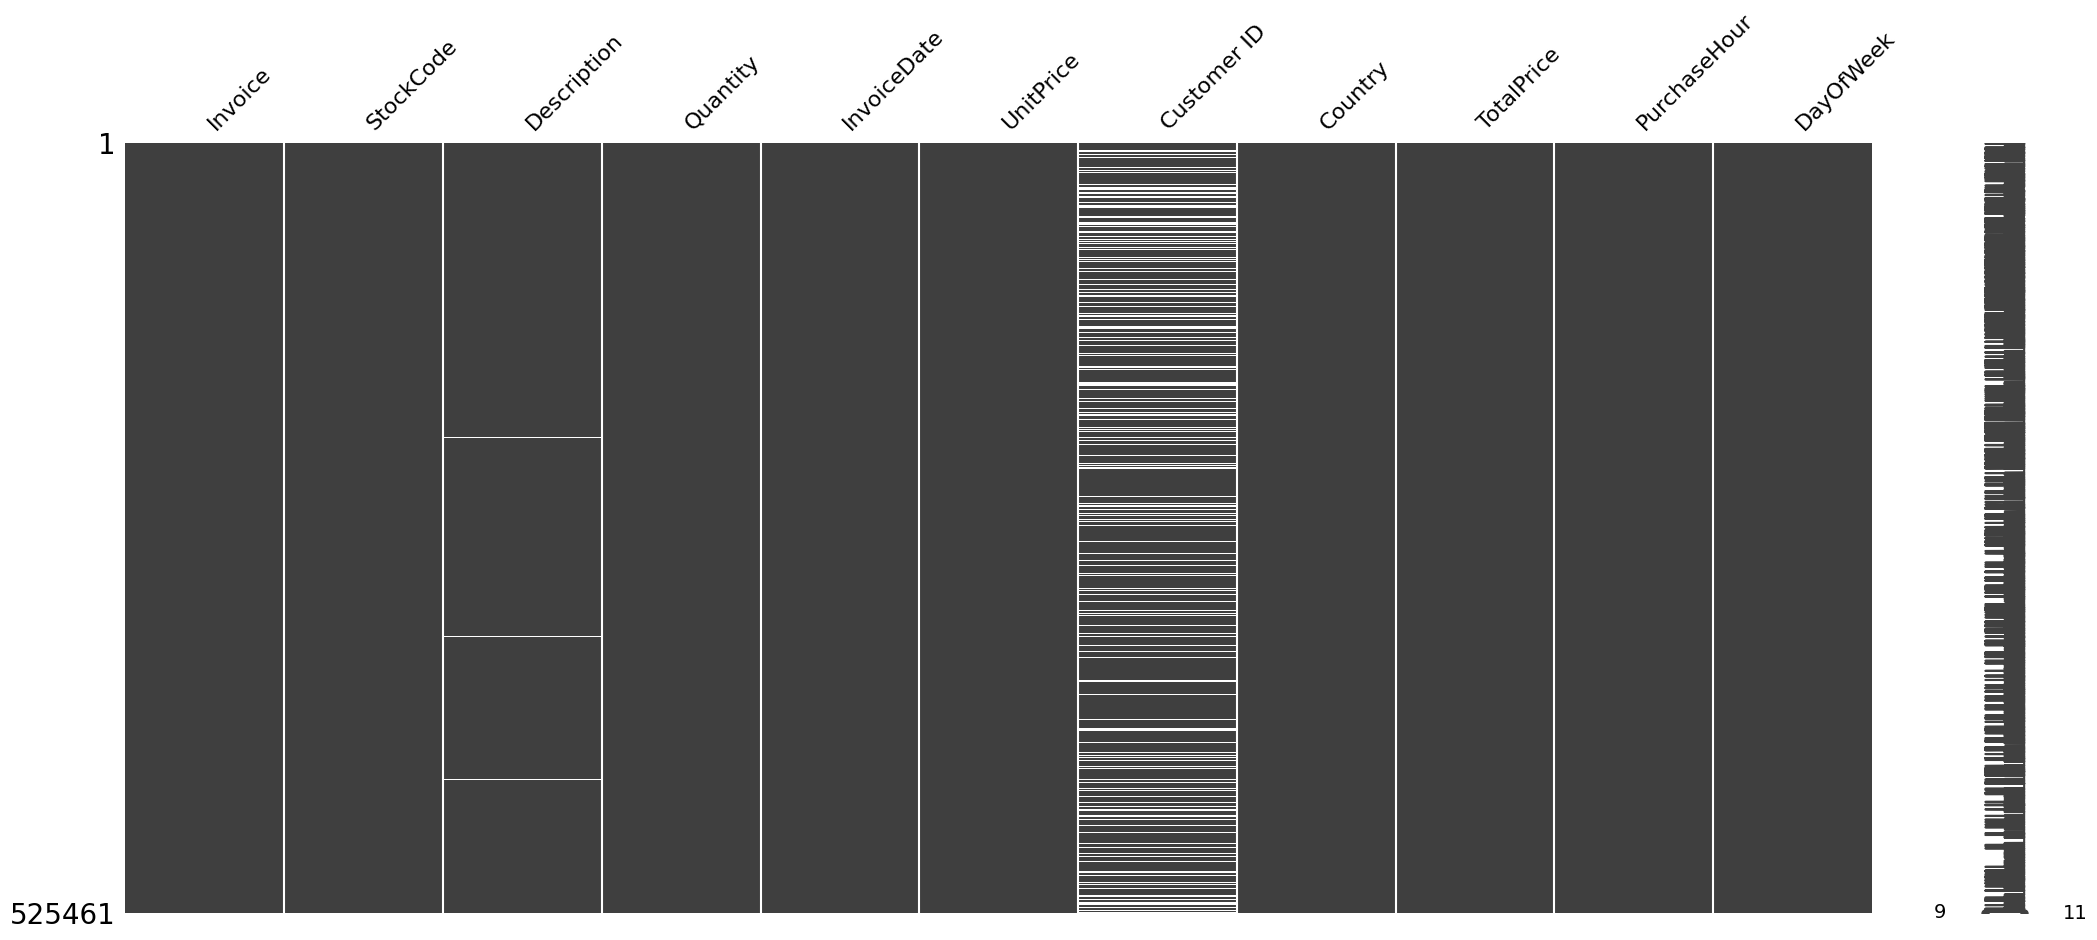

In [11]:
msno.matrix(df)
plt.show()

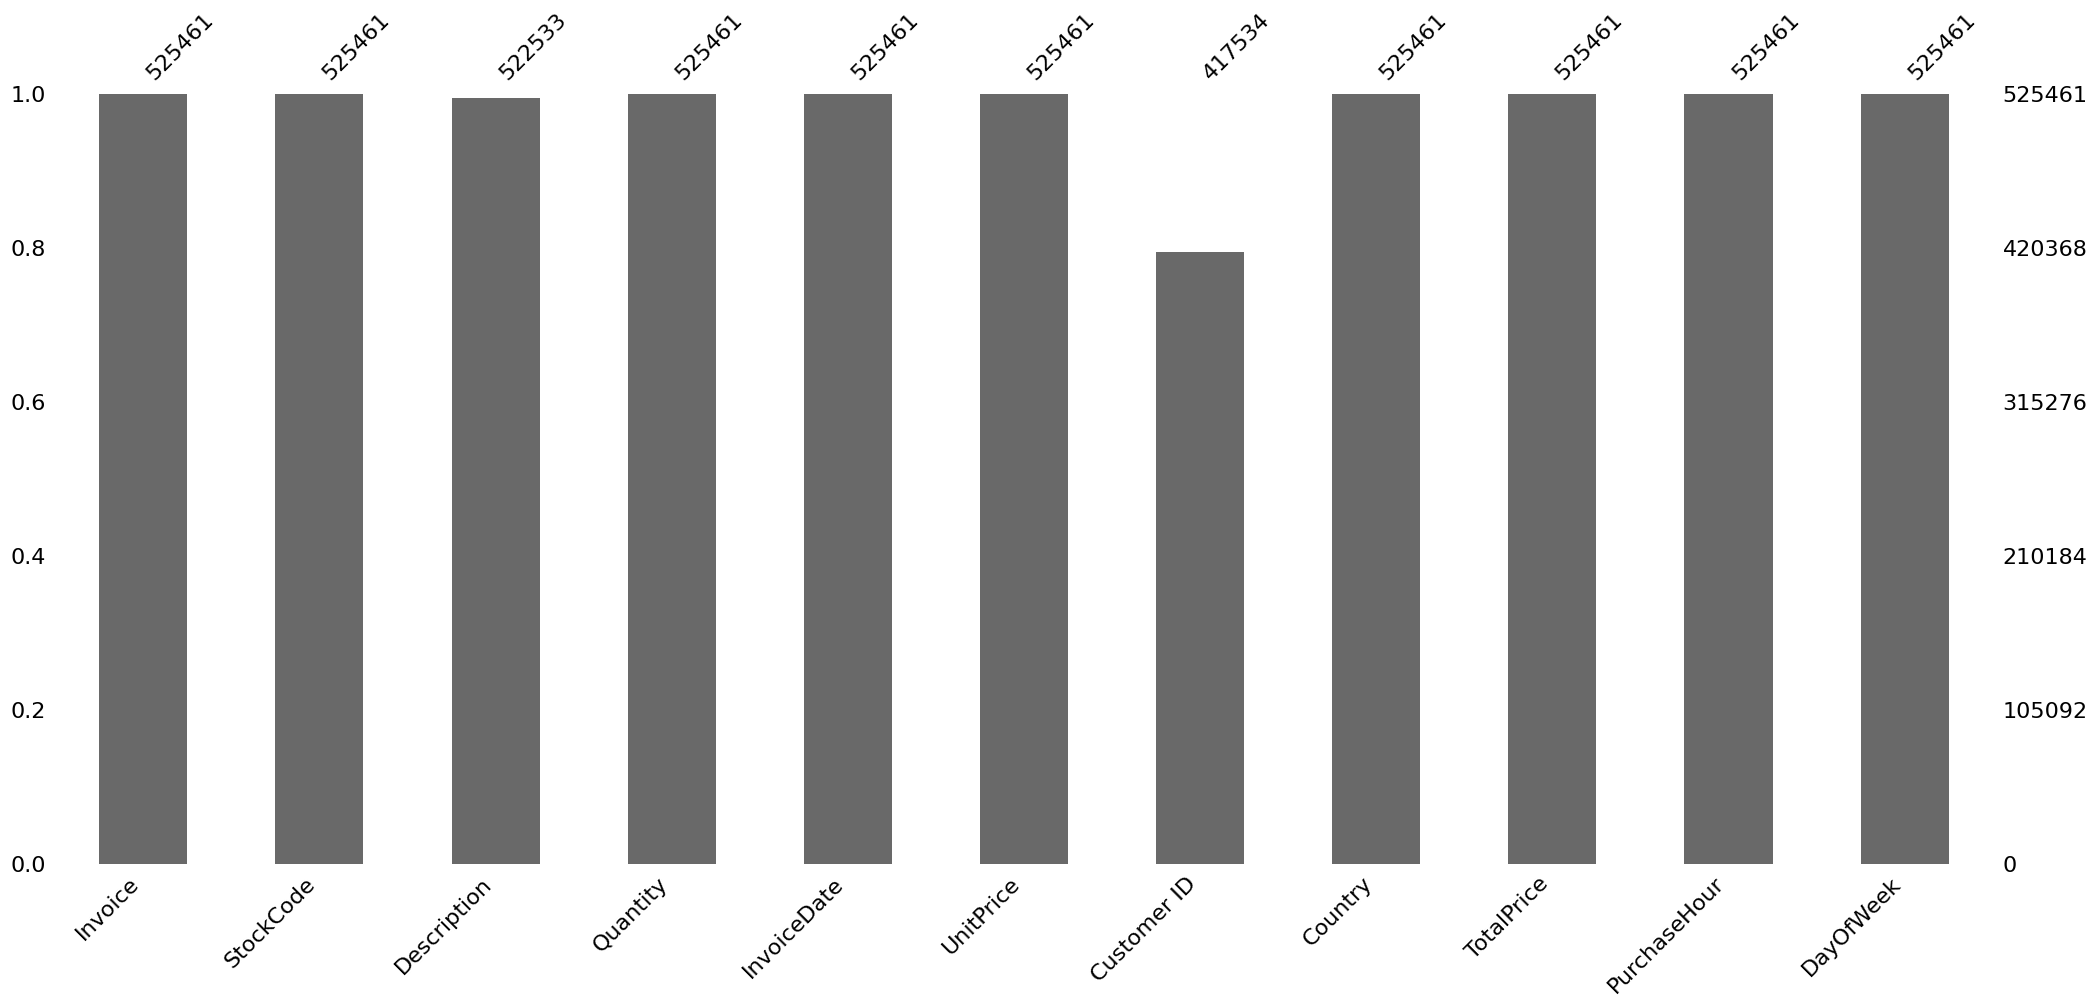

In [12]:
msno.bar(df)
plt.show()

In [13]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 6865


In [14]:
print("Countries :", df["Country"].nunique())

print("Products :", df["StockCode"].nunique())

print("Customers :", df["Customer ID"].nunique())

print("Invoices :", df["Invoice"].nunique())

Countries : 40
Products : 4632
Customers : 4383
Invoices : 28816


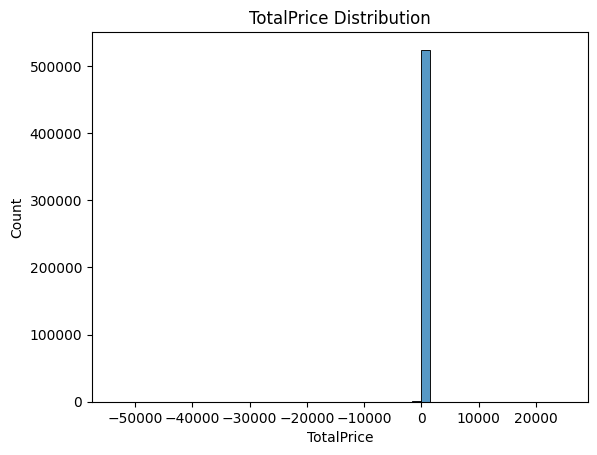

In [15]:
sns.histplot(df["TotalPrice"], bins=50)

plt.title("TotalPrice Distribution")

plt.show()

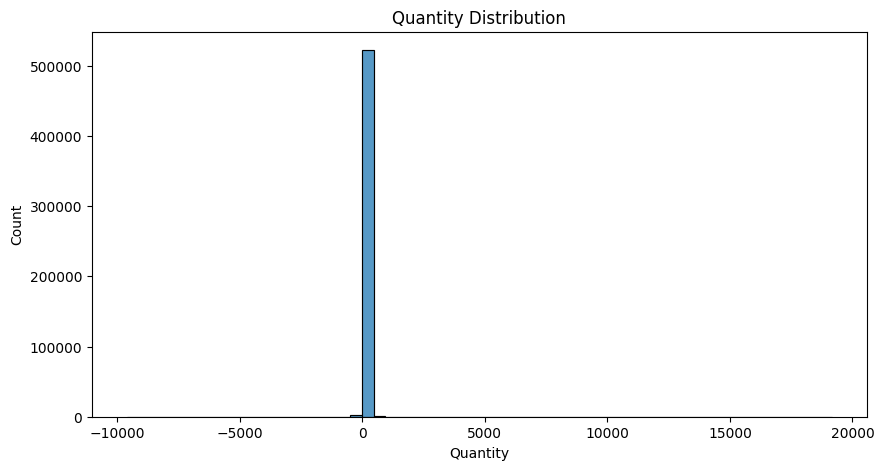

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(df["Quantity"], bins=60)

plt.title("Quantity Distribution")

plt.show()

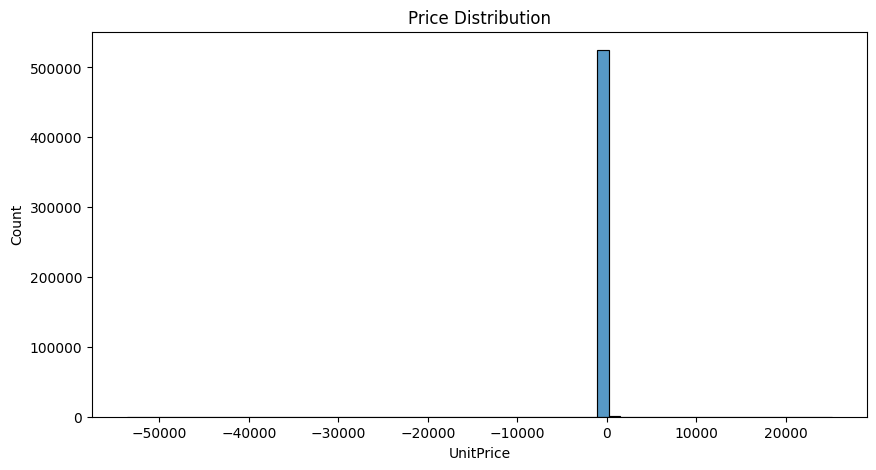

In [17]:
price_col = "UnitPrice" if "UnitPrice" in df.columns else "Price"

plt.figure(figsize=(10,5))

sns.histplot(df[price_col], bins=60)

plt.title("Price Distribution")

plt.show()

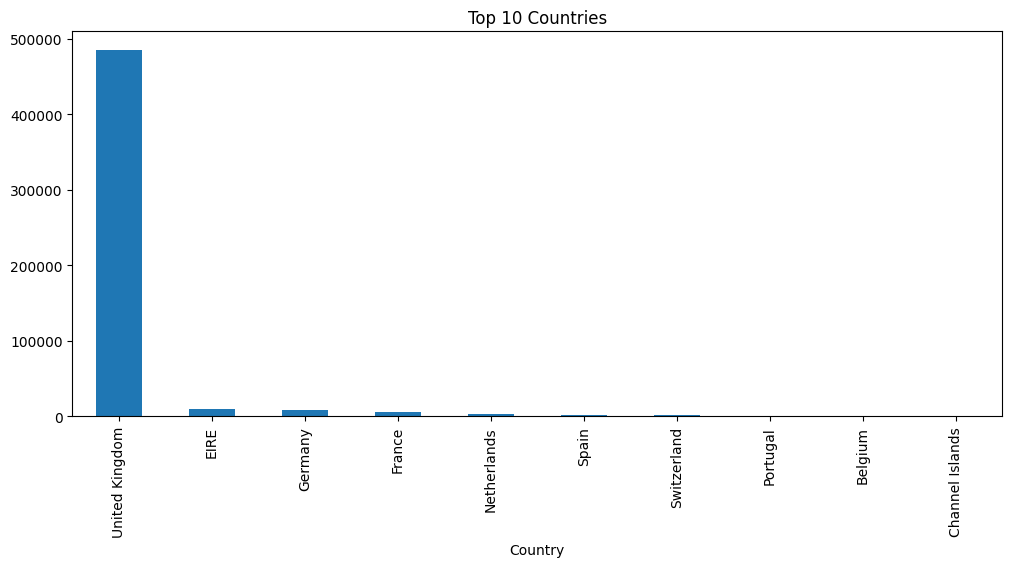

In [18]:
country_sales = (
    df["Country"]
      .value_counts()
      .head(10)
)

country_sales.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Top 10 Countries")

plt.show()

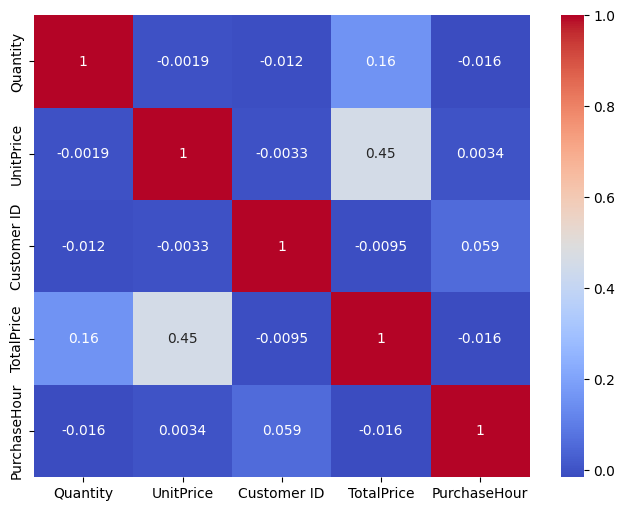

In [19]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [20]:
df.to_csv(
    "../data/processed/raw_loaded.csv",
    index=False
)